In [ ]:
''' !pip uninstall -y scikit-learn
!pip install scikit-learn==1.3.1 '''

' !pip uninstall -y scikit-learn\n!pip install scikit-learn==1.3.1 '

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


!ls /content/drive/MyDrive/Dissertação/CSvs

Mounted at /content/drive
 Binance_ADAUSDT_d.csv	  Binance_MATICUSDT_d.csv   model_outputs_block.pkl
 Binance_AVAXUSDT_d.csv   Binance_SOLUSDT_d.csv     model_outputs_tech.pkl
 Binance_BTCUSDT_d.csv	  Binance_XRPUSDT_d.csv     results_by_horizon.pkl
 Binance_ETHUSDT_d.csv	 'Cópia de btc.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar apenas os dados do Bitcoin (BTCUSDT)
btc_path = '/content/drive/MyDrive/Dissertação/CSvs/Binance_BTCUSDT_d.csv'
Binance_BTCUSDT_d = pd.read_csv(btc_path, header=1)


In [ ]:
Binance_BTCUSDT_d = Binance_BTCUSDT_d.iloc[:, 1:].drop(columns = 'Symbol').sort_values(by='Date').set_index('Date')
Binance_BTCUSDT_d['Close_t+1'] = Binance_BTCUSDT_d['Close'].shift(-1)
Binance_BTCUSDT_d['Close_Diff'] = Binance_BTCUSDT_d['Close'].diff()
Binance_BTCUSDT_d['Direction_t+1'] = np.where(Binance_BTCUSDT_d['Close_t+1'] > Binance_BTCUSDT_d['Close'], 1, 0)

In [ ]:
Binance_BTCUSDT_d.head()

,Open,High,Low,Close,Volume BTC,Volume USDT,tradecount,Close_t+1,Close_Diff,Direction_t+1
Date,,,,,,,,,,
2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377,3.454770e+06,3427,4108.37,NaN,0
2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264,5.086958e+06,5233,4139.98,-176.71,1
2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763,1.549484e+06,2153,4086.29,31.61,0
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,1.930364e+06,2321,4016.00,-53.69,0
2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060,2.797232e+06,3972,4040.00,-70.29,1


In [ ]:
Binance_BTCUSDT_d['Direction_t+1'].value_counts()

,count
Direction_t+1,
1,1233
0,1160


In [ ]:
''' from matplotlib.gridspec import GridSpec

def plot_feature_transformations(df, feature):
    fig = plt.figure(figsize=(15, 12))
    gs = GridSpec(3, 1, figure=fig)

    # Original feature
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df.index, df[feature])
    ax1.set_title(f'Original {feature}')
    ax1.set_xlabel('Date')
    ax1.set_ylabel(feature)

    # Differenced feature
    ax2 = fig.add_subplot(gs[1, 0])
    differenced = df[feature].diff()
    ax2.plot(df.index, differenced)
    ax2.set_title(f'Differenced {feature}')
    ax2.set_xlabel('Date')
    ax2.set_ylabel(f'Diff {feature}')

    # Log-differenced feature
    ax3 = fig.add_subplot(gs[2, 0])
    log_differenced = np.log(df[feature]).diff()
    ax3.plot(df.index, log_differenced)
    ax3.set_title(f'Log-Differenced {feature}')
    ax3.set_xlabel('Date')
    ax3.set_ylabel(f'Log-Diff {feature}')

    plt.tight_layout()
    plt.show()

# Assuming your dataframe is named Binance_BTCUSDT_d
features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']

for feature in features:
    plot_feature_transformations(Binance_BTCUSDT_d, feature) '''

" from matplotlib.gridspec import GridSpec\n\ndef plot_feature_transformations(df, feature):\n    fig = plt.figure(figsize=(15, 12))\n    gs = GridSpec(3, 1, figure=fig)\n\n    # Original feature\n    ax1 = fig.add_subplot(gs[0, 0])\n    ax1.plot(df.index, df[feature])\n    ax1.set_title(f'Original {feature}')\n    ax1.set_xlabel('Date')\n    ax1.set_ylabel(feature)\n\n    # Differenced feature\n    ax2 = fig.add_subplot(gs[1, 0])\n    differenced = df[feature].diff()\n    ax2.plot(df.index, differenced)\n    ax2.set_title(f'Differenced {feature}')\n    ax2.set_xlabel('Date')\n    ax2.set_ylabel(f'Diff {feature}')\n\n    # Log-differenced feature\n    ax3 = fig.add_subplot(gs[2, 0])\n    log_differenced = np.log(df[feature]).diff()\n    ax3.plot(df.index, log_differenced)\n    ax3.set_title(f'Log-Differenced {feature}')\n    ax3.set_xlabel('Date')\n    ax3.set_ylabel(f'Log-Diff {feature}')\n\n    plt.tight_layout()\n    plt.show()\n\n# Assuming your dataframe is named Binance_BTCUSDT_d

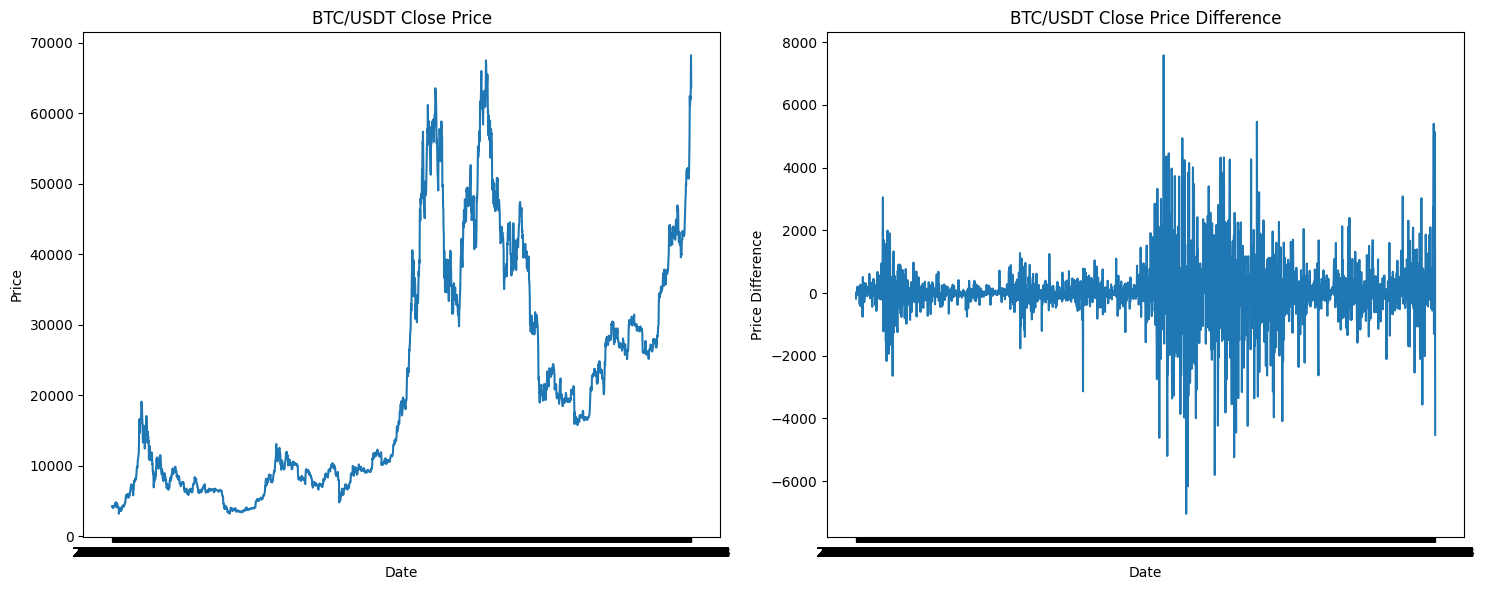

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 'Close' on the first subplot
ax1.plot(Binance_BTCUSDT_d.index, Binance_BTCUSDT_d['Close'])
ax1.set_title('BTC/USDT Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Plot 'Close_Diff' on the second subplot
ax2.plot(Binance_BTCUSDT_d.index, Binance_BTCUSDT_d['Close_Diff'])
ax2.set_title('BTC/USDT Close Price Difference')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price Difference')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
transf_features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']

def log_diff_transform(series):
    # Add a small constant to avoid log(0)
    return np.log(series + 1).diff()

# Create a new dataframe with log-differenced features
Binance_BTCUSDT_d_transformed = pd.DataFrame(index=Binance_BTCUSDT_d.index)

# Add transformed features
for feature in transf_features:
    new_column_name = f'log_diff_{feature.lower().replace(" ", "_")}'
    Binance_BTCUSDT_d_transformed[new_column_name] = log_diff_transform(Binance_BTCUSDT_d[feature])

# Add the Close column without transformation
Binance_BTCUSDT_d_transformed['Close'] = Binance_BTCUSDT_d['Close']

# Remove the first row which will contain NaN values due to differencing
Binance_BTCUSDT_d_transformed = Binance_BTCUSDT_d_transformed.dropna()

# Display the first few rows of the transformed dataframe
print(Binance_BTCUSDT_d_transformed.head())

# Display summary statistics
print(Binance_BTCUSDT_d_transformed.describe())

# Check for any remaining NaN values
print("\nNumber of NaN values in each column:")
print(Binance_BTCUSDT_d_transformed.isna().sum())

            log_diff_open  log_diff_high  log_diff_low  log_diff_close  \
Date                                                                     
2017-08-18       0.005521      -0.025709     -0.064376       -0.042103   
2017-08-19      -0.042103      -0.043668     -0.022789        0.007663   
2017-08-20       0.003064       0.006285      0.046331       -0.013050   
2017-08-21      -0.012659      -0.021953     -0.030414       -0.017347   
2017-08-22      -0.013140      -0.003598     -0.140181        0.005957   

            log_diff_volume_btc  log_diff_volume_usdt  log_diff_tradecount  \
Date                                                                         
2017-08-18             0.411029              0.386924             0.423199   
2017-08-19            -1.144586             -1.188758            -0.887849   
2017-08-20             0.202414              0.219787             0.075102   
2017-08-21             0.392013              0.370921             0.537093   
2017-08-22   

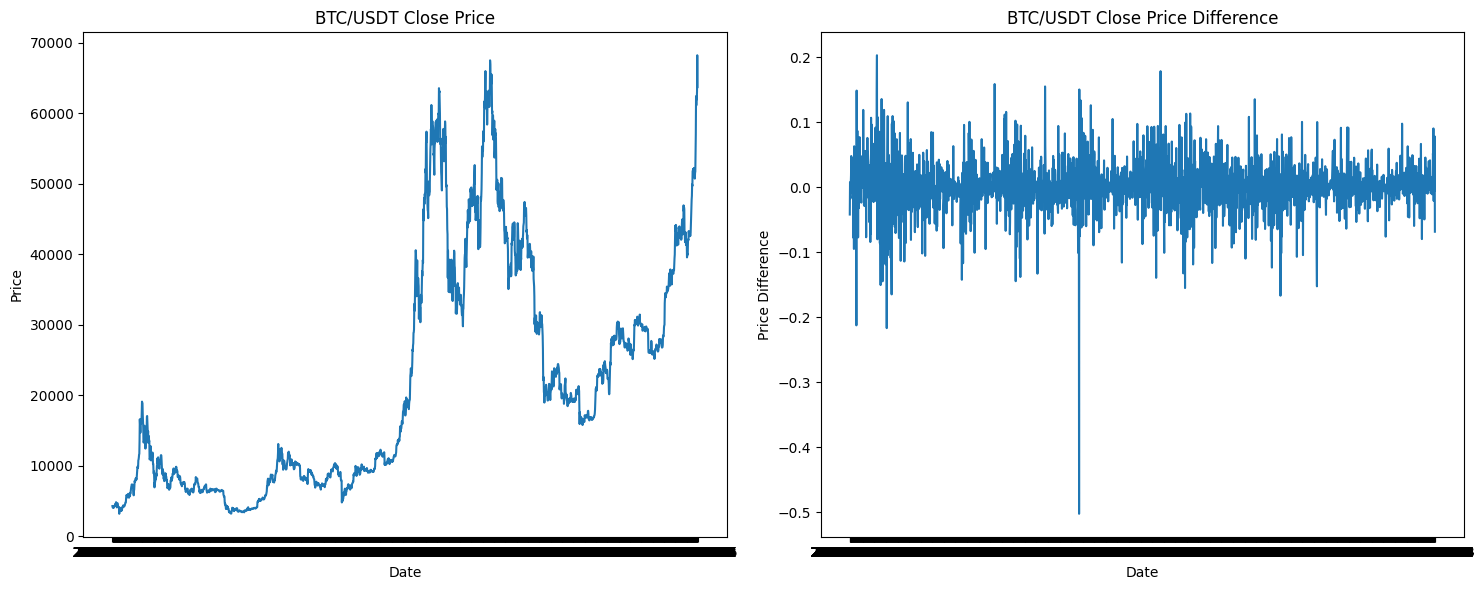

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 'Close' on the first subplot
ax1.plot(Binance_BTCUSDT_d.index, Binance_BTCUSDT_d['Close'])
ax1.set_title('BTC/USDT Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Plot 'Close_Diff' on the second subplot
ax2.plot(Binance_BTCUSDT_d_transformed.index, Binance_BTCUSDT_d_transformed['log_diff_close'])
ax2.set_title('BTC/USDT Close Price Difference')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price Difference')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
Binance_BTCUSDT_d_transformed.columns

Index(['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
       'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount',
       'Close'],
      dtype='object')

In [ ]:
Binance_BTCUSDT_d_transformed['Close_t+1'] = Binance_BTCUSDT_d_transformed['log_diff_close'].shift(-1)

Binance_BTCUSDT_d_transformed['Direction_t+1'] = np.where(Binance_BTCUSDT_d_transformed['Close_t+1'] > 0, 1, 0)

Binance_BTCUSDT_d_transformed.dropna(inplace=True)

In [ ]:
def create_multi_period_targets(df, periods=[1, 3, 7, 14, 30], threshold_multiplier=0.75):
    """
    Cria variáveis target para múltiplas janelas temporais

    Parameters:
    df: DataFrame com coluna 'close' contendo preços
    periods: lista com períodos para análise
    threshold_multiplier: multiplicador para ajustar sensibilidade dos limiares

    Returns:
    DataFrame original com novas colunas de target para cada período
    """

    df_copy = df.copy()

    for period in periods:
        # Calcular retornos percentuais para o período
        returns = df_copy['Close'].pct_change(periods=period)

        # Calcular volatilidade histórica
        volatility = returns.rolling(window=20).std()

        # Definir limiares dinâmicos
        upper_threshold = threshold_multiplier * volatility
        lower_threshold = -threshold_multiplier * volatility

        # Criar variável target
        target = np.ones(len(returns))  # Inicializa com 1 (manter)
        target[returns > upper_threshold] = 2    # Sinal de compra (era 1, agora é 2)
        target[returns < lower_threshold] = 0    # Sinal de venda (era -1, agora é 0)

        # Adicionar ao DataFrame com nome específico para o período
        column_name = f'target_{period}d'
        df_copy[column_name] = target

    return df_copy

# Exemplo de uso
# Assumindo que df é seu DataFrame com coluna 'close'
periods = [1, 3, 7, 14, 30]
df_with_targets = create_multi_period_targets(Binance_BTCUSDT_d_transformed, periods=periods, threshold_multiplier=0.75)

# Criar um dataframe com as variáveis originais sem transformação
Binance_BTCUSDT_d_original = Binance_BTCUSDT_d.copy()

# Criar os targets da mesma forma para garantir comparabilidade
df_with_targets_original = create_multi_period_targets(Binance_BTCUSDT_d_original, periods=[1, 3, 7, 14, 30], threshold_multiplier=0.75)


def analyze_targets(df, periods=[1, 3, 7, 14, 30]):
    """
    Analisa as variáveis target criadas
    """
    analysis = {}

    for period in periods:
        column_name = f'target_{period}d'
        target = df[column_name]

        # Calcular métricas
        metrics = {
            'total_sinais': len(target),
            'sinais_venda': sum(target == 0),    # Venda agora é 0
            'sem_acao': sum(target == 1),        # Manter é 1
            'sinais_compra': sum(target == 2),   # Compra agora é 2
            'prop_venda': sum(target == 0) / len(target),
            'prop_sem_acao': sum(target == 1) / len(target),
            'prop_compra': sum(target == 2) / len(target)
        }

        analysis[period] = metrics

    return pd.DataFrame(analysis).T

# Usar a função de análise
analysis_df = analyze_targets(df_with_targets, periods)
print("\nAnálise detalhada das variáveis target:")
print(analysis_df)

# Adicionar análise de correlação entre as diferentes janelas temporais
correlation_matrix = df_with_targets[[f'target_{p}d' for p in periods]].corr()
print("\nMatriz de correlação entre as variáveis target:")
print(correlation_matrix)


Análise detalhada das variáveis target:
    total_sinais  sinais_venda  sem_acao  sinais_compra  prop_venda  \
1         2391.0         396.0    1528.0          467.0    0.165621   
3         2391.0         466.0    1345.0          580.0    0.194898   
7         2391.0         521.0    1158.0          712.0    0.217900   
14        2391.0         631.0     892.0          868.0    0.263906   
30        2391.0         774.0     635.0          982.0    0.323714   

    prop_sem_acao  prop_compra  
1        0.639063     0.195316  
3        0.562526     0.242576  
7        0.484316     0.297783  
14       0.373066     0.363028  
30       0.265579     0.410707  

Matriz de correlação entre as variáveis target:
            target_1d  target_3d  target_7d  target_14d  target_30d
target_1d    1.000000   0.500399   0.326529    0.238642    0.173176
target_3d    0.500399   1.000000   0.559570    0.388751    0.261073
target_7d    0.326529   0.559570   1.000000    0.607312    0.392082
target_14d   

In [ ]:
df_with_targets.to_parquet('df_with_targets.parquet')

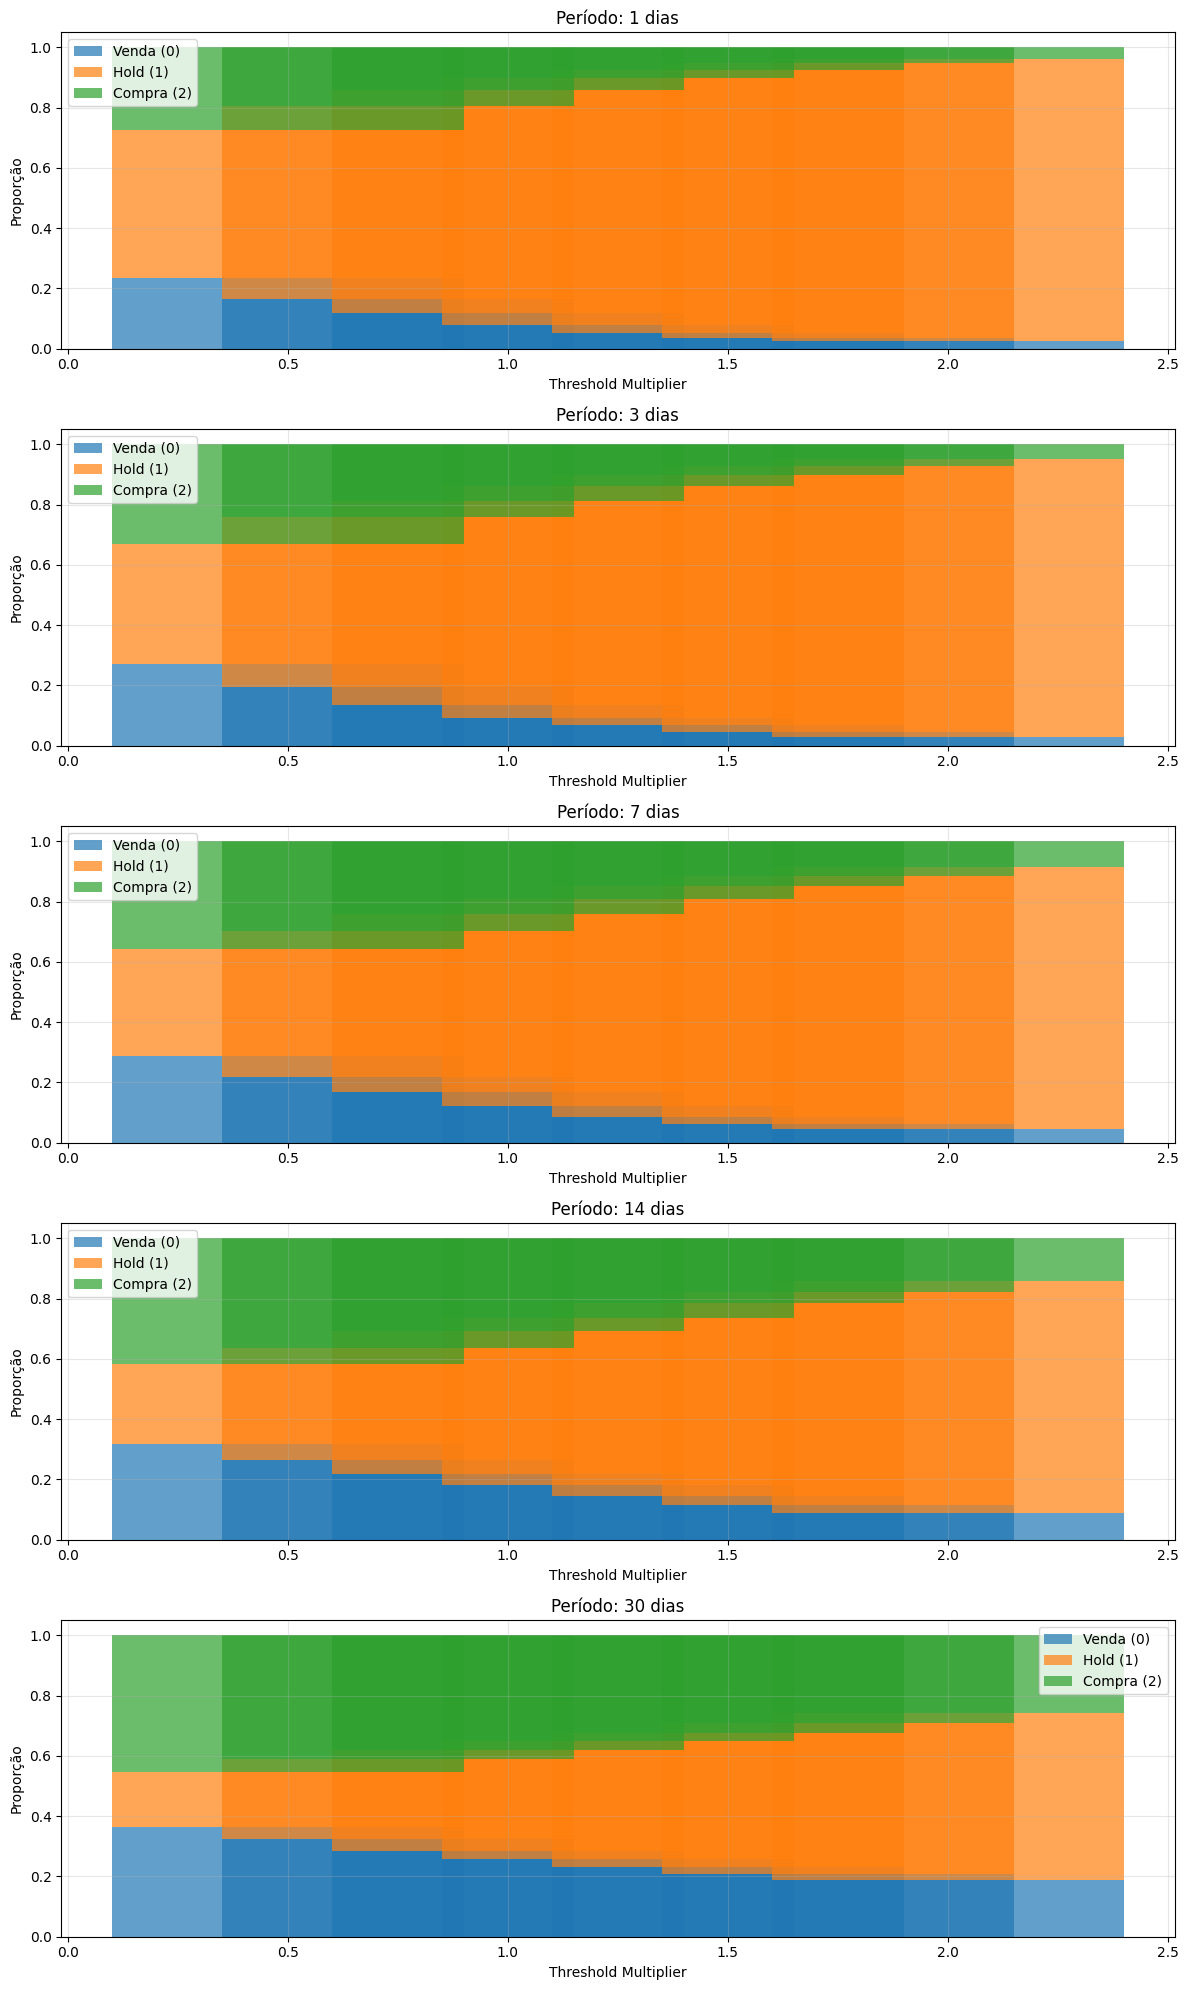


Threshold: 0.5
Período 1d: Venda=0.235, Hold=0.492, Compra=0.273
Período 3d: Venda=0.272, Hold=0.396, Compra=0.332
Período 7d: Venda=0.287, Hold=0.355, Compra=0.358
Período 14d: Venda=0.319, Hold=0.266, Compra=0.416
Período 30d: Venda=0.363, Hold=0.184, Compra=0.452

Threshold: 0.75
Período 1d: Venda=0.166, Hold=0.639, Compra=0.195
Período 3d: Venda=0.195, Hold=0.563, Compra=0.243
Período 7d: Venda=0.218, Hold=0.484, Compra=0.298
Período 14d: Venda=0.264, Hold=0.373, Compra=0.363
Período 30d: Venda=0.324, Hold=0.266, Compra=0.411

Threshold: 1.0
Período 1d: Venda=0.117, Hold=0.740, Compra=0.143
Período 3d: Venda=0.136, Hold=0.676, Compra=0.187
Período 7d: Venda=0.169, Hold=0.590, Compra=0.242
Período 14d: Venda=0.219, Hold=0.473, Compra=0.308
Período 30d: Venda=0.285, Hold=0.334, Compra=0.381

Threshold: 1.25
Período 1d: Venda=0.079, Hold=0.819, Compra=0.102
Período 3d: Venda=0.093, Hold=0.768, Compra=0.139
Período 7d: Venda=0.120, Hold=0.688, Compra=0.191
Período 14d: Venda=0.183, Ho

In [ ]:
def analyze_threshold_effects(df, periods=[1, 3, 7, 14, 30], thresholds=np.arange(0.5, 2.25, 0.25)):
    """
    Analisa o efeito de diferentes thresholds na distribuição das classes

    Parameters:
    df: DataFrame com dados
    periods: lista de períodos para análise
    thresholds: array com valores de threshold para testar
    """

    results = {}

    # Para cada threshold
    for thresh in thresholds:
        # Gerar targets
        df_targets = create_multi_period_targets(df, periods=periods, threshold_multiplier=thresh)

        # Calcular distribuição das classes para cada período
        dist = {}
        for period in periods:
            col = f'target_{period}d'
            values, counts = np.unique(df_targets[col], return_counts=True)
            dist[period] = dict(zip(values, counts/len(df_targets)))

        results[thresh] = dist

    # Plotar resultados
    fig, axes = plt.subplots(len(periods), 1, figsize=(12, 4*len(periods)))
    #fig.suptitle('Distribuição das Classes por Threshold e Período', y = 1.01)

    for i, period in enumerate(periods):
        ax = axes[i]

        # Extrair dados para plot
        thresh_values = list(results.keys())
        sells = [results[t][period].get(0, 0) for t in thresh_values]
        holds = [results[t][period].get(1, 0) for t in thresh_values]
        buys = [results[t][period].get(2, 0) for t in thresh_values]

        # Plot empilhado
        ax.bar(thresh_values, sells, label='Venda (0)', alpha=0.7)
        ax.bar(thresh_values, holds, bottom=sells, label='Hold (1)', alpha=0.7)
        ax.bar(thresh_values, buys, bottom=np.array(sells)+np.array(holds), label='Compra (2)', alpha=0.7)

        ax.set_xlabel('Threshold Multiplier')
        ax.set_ylabel('Proporção')
        ax.set_title(f'Período: {period} dias')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('threshold_analysis.png')
    plt.show()

    return results

# Executar análise
thresholds = np.arange(0.5, 2.25, 0.25)
results = analyze_threshold_effects(df_with_targets, periods=[1, 3, 7, 14, 30], thresholds=thresholds)

# Imprimir resultados numéricos
for thresh in thresholds:
    print(f"\nThreshold: {thresh}")
    for period in [1, 3, 7, 14, 30]:
        dist = results[thresh][period]
        print(f"Período {period}d: Venda={dist.get(0, 0):.3f}, Hold={dist.get(1, 0):.3f}, Compra={dist.get(2, 0):.3f}")

## Adding windows transformed DF

In [ ]:
# Definção hiperparâmetros e lags
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

def find_best_lags(data, feature_cols, target_column, max_lags, models, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_lags = {}

    for model_name, model in models.items():
        best_score = -1
        best_num_lags = None

        for num_lags in range(1, max_lags + 1):
            features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, num_lags + 1)]
            X = pd.concat([data[features], data[feature_cols]], axis=1)
            y = data[target_column]

            scores = []
            for train_idx, test_idx in tscv.split(X):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                scores.append(accuracy_score(y_test, y_pred))

            mean_score = np.mean(scores)

            if mean_score > best_score:
                best_score = mean_score
                best_num_lags = num_lags

        best_lags[model_name] = {"best_lags": best_num_lags, "best_score": best_score}

    return best_lags


def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    lagged_dfs = []

    for col_name in col_names:
        lagged_features = pd.concat([df_copy[col_name].shift(i).rename(f'{col_name}_t-{i}')
                                   for i in range(1, max_lags + 1)], axis=1)
        lagged_dfs.append(lagged_features)

    result = pd.concat([df_copy] + lagged_dfs, axis=1)
    return result

def prepare_data(df, feature_cols, max_lags, target_column):
    df_prepared = create_lagged_features(df, feature_cols, max_lags)
    df_prepared = df_prepared.dropna()
    return df_prepared

def tune_models_with_best_lags(data, feature_cols, target_column, best_lags, models_and_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = {}

    for model_name, model_info in models_and_params.items():
        num_lags = best_lags[model_name]["best_lags"]
        features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, num_lags + 1)]
        X = pd.concat([data[features], data[feature_cols]], axis=1)
        y = data[target_column]

        search = RandomizedSearchCV(
            estimator=model_info["model"],
            param_distributions=model_info["params"],
            n_iter=10,
            scoring='f1_weighted',
            cv=tscv,
            random_state=42,
            n_jobs=-1
        )

        search.fit(X, y)
        results[model_name] = {
            "best_params": search.best_params_,
            "best_score": search.best_score_,
            "best_lags": num_lags
        }

    return results


# Main execution
max_lags = 20
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

models_and_params = {
    "XGBoost": {
        "model": XGBClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0]
        }
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs", "saga"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    }
}

# Modelos com parâmetros padrão para avaliação inicial de lags
models = {
    "XGBoost": XGBClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results_by_horizon = {}

for horizon in target_horizons:
    target_column = f'target_{horizon}d'
    df_prepared = prepare_data(df_with_targets, feature_cols, max_lags, target_column)

    # Passo 1: Encontrar os melhores lags
    best_lags = find_best_lags(df_prepared, feature_cols, target_column, max_lags, models)

    # Passo 2: Afinar os hiperparâmetros com os melhores lags
    results_by_horizon[horizon] = tune_models_with_best_lags(
        df_prepared, feature_cols, target_column, best_lags, models_and_params
    )

# Imprimir os resultados
for horizon, results in results_by_horizon.items():
    print(f"\nResults for horizon {horizon} days:")
    for model_name, result in results.items():
        print(f"\n  Model: {model_name}")
        print(f"    Best Params: {result['best_params']}")
        print(f"    Best Score: {result['best_score']:.4f}")
        print(f"    Best Number of Lags: {result['best_lags']}")


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/


Results for horizon 1 days:

  Model: XGBoost
    Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}
    Best Score: 0.8990
    Best Number of Lags: 12

  Model: SVM
    Best Params: {'kernel': 'linear', 'gamma': 'auto', 'C': 10}
    Best Score: 0.8164
    Best Number of Lags: 1

  Model: Logistic Regression
    Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}
    Best Score: 0.8031
    Best Number of Lags: 5

  Model: Random Forest
    Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
    Best Score: 0.8727
    Best Number of Lags: 2

Results for horizon 3 days:

  Model: XGBoost
    Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
    Best Score: 0.8323
    Best Number of Lags: 5

  Model: SVM
    Best Params: {'kernel': 'linear', 'gamma': 'auto', 'C': 10}
    Best Score: 0.7650
    Best Number of Lags: 1

  Model: Logistic Regression
    Bes


Results for horizon 1 days (Model: XGBoost):
  Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}
  Best Number of Lags: 3
  Mean Accuracy: 0.8770
  Confusion Matrix (Summed over folds):
[[ 244   79    0]
 [  32 1185   50]
 [   0   82  303]]


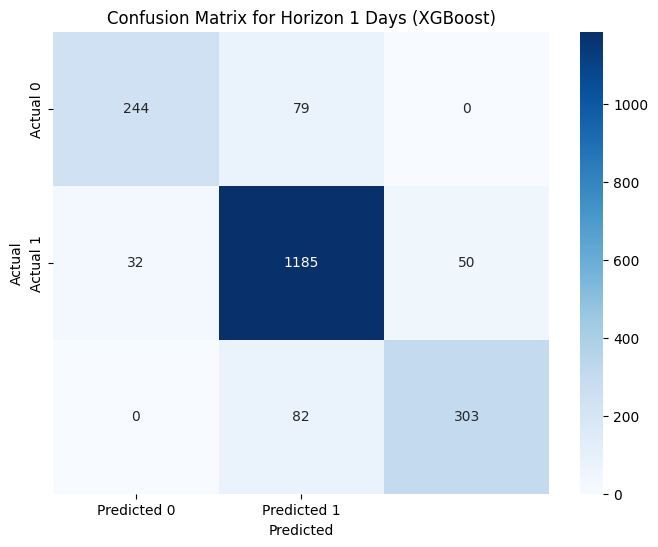


Results for horizon 3 days (Model: XGBoost):
  Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}
  Best Number of Lags: 4
  Mean Accuracy: 0.8020
  Confusion Matrix (Summed over folds):
[[ 229  151    0]
 [  39 1012   59]
 [   0  142  343]]


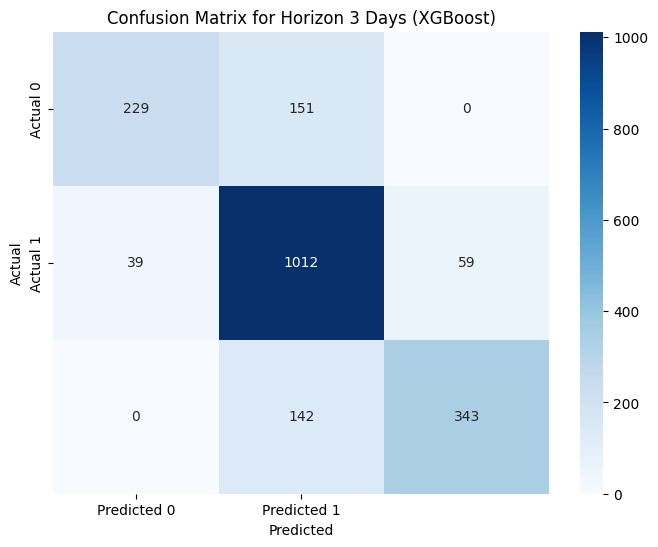


Results for horizon 7 days (Model: XGBoost):
  Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}
  Best Number of Lags: 13
  Mean Accuracy: 0.7023
  Confusion Matrix (Summed over folds):
[[219 190  10]
 [ 85 773 108]
 [  3 192 395]]


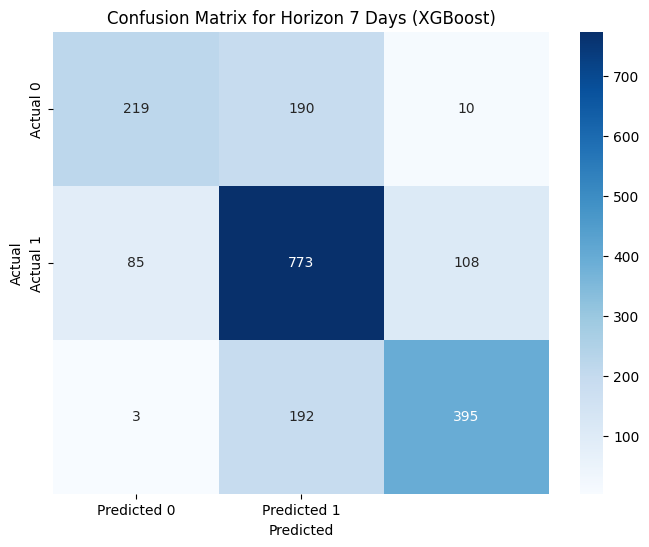


Results for horizon 14 days (Model: XGBoost):
  Best Params: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}
  Best Number of Lags: 20
  Mean Accuracy: 0.6273
  Confusion Matrix (Summed over folds):
[[262 219  28]
 [ 99 414 226]
 [  8 156 563]]


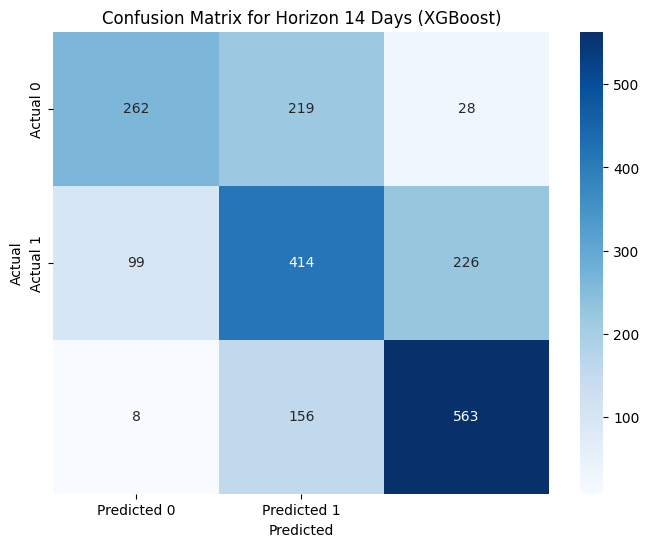


Results for horizon 30 days (Model: XGBoost):
  Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}
  Best Number of Lags: 14
  Mean Accuracy: 0.5438
  Confusion Matrix (Summed over folds):
[[379 123 135]
 [174 120 189]
 [160 120 575]]


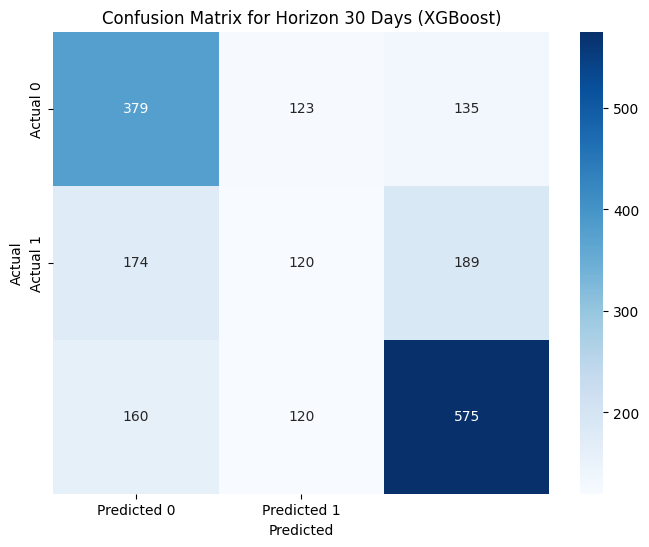

In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    lagged_dfs = []

    for col_name in col_names:
        lagged_features = pd.concat([df_copy[col_name].shift(i).rename(f'{col_name}_t-{i}')
                                      for i in range(1, max_lags + 1)], axis=1)
        lagged_dfs.append(lagged_features)

    result = pd.concat([df_copy] + lagged_dfs, axis=1)
    return result

def prepare_data(df, feature_cols, max_lags, target_column):
    df_prepared = create_lagged_features(df, feature_cols, max_lags)
    df_prepared = df_prepared.dropna()
    return df_prepared

# Best parameters and lags obtained in the previous execution
best_params_lags = {
    1: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 3},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 1},
    },
    3: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 4},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 4},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 3},
    },
    7: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 13},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 7},
    },
    14: {
        "XGBoost": {'best_params': {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 20},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}, 'best_lags': 16},
        "Random Forest": {'best_params': {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 14},
    },
    30: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 14},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 3},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}, 'best_lags': 8},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 8},
    }
}

# Main execution
max_lags_overall = 20 # Maximum possible lag to ensure data preparation works for all horizons
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

results_by_horizon = {}

for horizon in target_horizons:
    target_column = f'target_{horizon}d'
    df_prepared = prepare_data(df_with_targets, feature_cols, max_lags_overall, target_column) # Prepare with max possible lags

    # Select the best model for each horizon based on previous results (XGBoost was generally the best)
    best_model_name = "XGBoost"
    best_config = best_params_lags[horizon][best_model_name]
    best_params = best_config['best_params']
    best_num_lags = best_config['best_lags']

    features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, best_num_lags + 1)]
    X = pd.concat([df_prepared[features], df_prepared[feature_cols]], axis=1)
    y = df_prepared[target_column]

    tscv = TimeSeriesSplit(n_splits=5)
    all_conf_matrices = []
    all_accuracy_scores = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Initialize and train the best model with best parameters
        model = XGBClassifier(**best_params, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        all_accuracy_scores.append(accuracy)
        all_conf_matrices.append(conf_matrix)

    mean_accuracy = np.mean(all_accuracy_scores)
    sum_conf_matrix = np.sum(all_conf_matrices, axis=0) # Sum confusion matrices for average representation

    results_by_horizon[horizon] = {
        "model_name": best_model_name,
        "best_params": best_params,
        "best_lags": best_num_lags,
        "mean_accuracy": mean_accuracy,
        "confusion_matrix": sum_conf_matrix
    }

# Imprimir os resultados e matrizes de confusão
for horizon, result in results_by_horizon.items():
    print(f"\nResults for horizon {horizon} days (Model: {result['model_name']}):")
    print(f"  Best Params: {result['best_params']}")
    print(f"  Best Number of Lags: {result['best_lags']}")
    print(f"  Mean Accuracy: {result['mean_accuracy']:.4f}")
    print(f"  Confusion Matrix (Summed over folds):\n{result['confusion_matrix']}")

    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for Horizon {horizon} Days ({result["model_name"]})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Parâmetros já definidos
target_horizons = [3, 7, 30]


def simulate_strategy(df, horizon, feature_cols, best_params_lags):
    target_column = f'target_{horizon}d'
    best_config = best_params_lags[horizon]["XGBoost"]
    best_params = best_config["best_params"]
    best_lags = best_config["best_lags"]

    # Criar variáveis defasadas
    lagged_features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, best_lags + 1)]
    df_lagged = create_lagged_features(df, feature_cols, best_lags).dropna()

    # Inputs e alinhamento
    X = df_lagged[lagged_features + feature_cols]
    y = df_lagged[target_column]
    close_today = df_lagged['Close']
    close_future = df_lagged['Close'].shift(-horizon)

    # Garantir índices alinhados
    valid_idx = X.index.intersection(close_future.dropna().index)
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]
    close_today = close_today.loc[valid_idx]
    close_future = close_future.loc[valid_idx]

    # Divisão temporal
    split = int(0.7 * len(X))
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    close_today_test = close_today.iloc[split:]
    close_future_test = close_future.iloc[split:]

    # Treinar modelo
    model = XGBClassifier(random_state=42, **best_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Simular retornos
    strategy_returns = []
    bh_returns = []

    for i in range(len(preds)):
        signal = preds[i]
        p_now = close_today_test.iloc[i]
        p_future = close_future_test.iloc[i]

        # Estratégia baseada na previsão
        if signal == 2:  # compra
            ret = (p_future / p_now) - 1
        elif signal == 0:  # venda
            ret = (p_now / p_future) - 1
        else:
            ret = 0
        strategy_returns.append(ret)

        # Buy and hold para o mesmo período
        bh_ret = (p_future / p_now) - 1
        bh_returns.append(bh_ret)

    # Curvas de capital
    capital_strategy = np.cumprod([1 + r for r in strategy_returns])
    capital_bh = np.cumprod([1 + r for r in bh_returns])

    # Resultados
    return {
        "horizon": horizon,
        "accuracy": accuracy_score(y_test, preds),
        "total_return_strategy": capital_strategy[-1] - 1,
        "total_return_bh": capital_bh[-1] - 1,
        "curve_strategy": capital_strategy,
        "curve_bh": capital_bh
    }

# Execução para cada horizonte
results = []

plt.figure(figsize=(16, 6))

for i, h in enumerate(target_horizons):
    res = simulate_strategy(df_with_targets, h, feature_cols, best_params_lags)
    results.append(res)

    plt.plot(res["curve_strategy"], label=f'Strategy t+{h}')
    plt.plot(res["curve_bh"], linestyle='--', label=f'Buy & Hold t+{h}')

plt.title('Curva de Capital Simulada por Horizonte')
plt.xlabel('Períodos (test set)')
plt.ylabel('Capital Acumulado (Base = 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Exibir resumo
df_resultado = pd.DataFrame([{
    'Horizonte (dias)': r['horizon'],
    'Retorno Total - Estratégia': f"{r['total_return_strategy']:.2%}",
    'Retorno Total - Buy & Hold': f"{r['total_return_bh']:.2%}",
    'Taxa de Acerto': f"{r['accuracy']:.2%}"
} for r in results])

print(df_resultado.to_string(index=False))


In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Assuming these are defined from the previous code:
#   - df_with_targets (your original DataFrame with target columns)
#   - feature_cols (list of feature column names)
#   - target_horizons (list of forecast horizons)
#   - results_by_horizon (dictionary with the best lags and hyperparameters for each model and horizon)

# Example: target_horizons = [1, 3, 7, 14, 30]
# Example: results_by_horizon = { horizon: { "XGBoost": {"best_params": {...}, "best_lags": ...}, ... }, ... }

def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    lagged_dfs = []
    for col_name in col_names:
        lagged_features = pd.concat(
            [df_copy[col_name].shift(i).rename(f'{col_name}_t-{i}') for i in range(1, max_lags + 1)],
            axis=1
        )
        lagged_dfs.append(lagged_features)
    result = pd.concat([df_copy] + lagged_dfs, axis=1)
    return result

# Container to store classification metrics for each model and horizon
classification_results = []

# Loop over each forecast horizon
for horizon in target_horizons:
    target_column = f'target_{horizon}d'
    best_results = results_by_horizon[horizon]

    for model_name, result in best_results.items():
        best_num_lags = result["best_lags"]
        best_params = result["best_params"]

        # Build the list of lagged feature names based on best_num_lags
        lagged_feature_names = [f'{col}_t-{i}' for col in feature_cols for i in range(1, best_num_lags + 1)]
        # Create features using lagged values and current feature values
        X = pd.concat([df_with_targets[lagged_feature_names], df_with_targets[feature_cols]], axis=1)
        y = df_with_targets[target_column]

        # Drop rows with missing values caused by shifting
        data = pd.concat([X, y], axis=1).dropna()
        X = data.drop(columns=target_column)
        y = data[target_column]

        # Split data into training (70%) and testing (30%) keeping the time series order intact
        split_index = int(0.7 * len(X))
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Instantiate the model with the best hyperparameters
        if model_name == "XGBoost":
            model = XGBClassifier(random_state=42, **best_params)
        elif model_name == "SVM":
            model = SVC(random_state=42, **best_params)
        elif model_name == "Logistic Regression":
            model = LogisticRegression(random_state=42, max_iter=1000, **best_params)
        elif model_name == "Random Forest":
            model = RandomForestClassifier(random_state=42, **best_params)
        else:
            continue  # Skip unknown models

        # Fit the model and predict on the test set
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Compute classification metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Append the results
        classification_results.append({
            "horizon": horizon,
            "model": model_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "best_num_lags": best_num_lags,
            "best_params": best_params
        })

# Convert the list of dictionaries into a DataFrame and save it to a CSV file
results_df = pd.DataFrame(classification_results)
results_df.to_csv("classification_metrics.csv", index=False)

print("Classification metrics saved to classification_metrics.csv")


TypeError: string indices must be integers, not 'str'

In [ ]:
results_by_horizon

### Friedman

In [ ]:
pip install scikit-posthocs

In [ ]:
from scipy.stats import friedmanchisquare
import pandas as pd
from scikit_posthocs import posthoc_nemenyi_friedman

# Organizando os resultados em um DataFrame
results = {
    "XGBoost": [0.8478, 0.8531, 0.8343, 0.8176, 0.7362],  # Scores para os horizontes
    "SVM": [0.7460, 0.7214, 0.7261, 0.7073, 0.7312],
    "Logistic Regression": [0.7470, 0.7231, 0.7260, 0.7201, 0.7355],
    "Random Forest": [0.8263, 0.7874, 0.7471, 0.7258, 0.7314]
}

# Criando o DataFrame
df_results = pd.DataFrame(results, index=["Horizon 1", "Horizon 3", "Horizon 7", "Horizon 14", "Horizon 30"])

# Inicializando um dicionário para armazenar resultados
results_summary = {}

# Get the scores for each model as separate lists
scores_xgboost = df_results["XGBoost"].tolist()
scores_svm = df_results["SVM"].tolist()
scores_logistic_regression = df_results["Logistic Regression"].tolist()
scores_random_forest = df_results["Random Forest"].tolist()

# Teste de Friedman
stat, p = friedmanchisquare(scores_xgboost, scores_svm, scores_logistic_regression, scores_random_forest)
# Calling friedmanchisquare with scores for each model across all horizons

print(f"Friedman Test Statistic: {stat}")
print(f"p-value: {p}")

if p < 0.05:
    print("Rejeitamos a hipótese nula: há diferenças significativas nos desempenhos dos modelos.")

    # Aplicando o teste pós-hoc de Nemenyi
    nemenyi_results = posthoc_nemenyi_friedman(df_results.T) # Transpose df_results

    print("Resultados do Teste de Nemenyi:")
    print(nemenyi_results)

    # ... (rest of the code for post-hoc analysis and results summary)
else:
    print("Não rejeitamos a hipótese nula: os desempenhos dos modelos não diferem significativamente.")

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

results = {
    "XGBoost": [0.8478, 0.8531, 0.8343, 0.8176, 0.7362],  # Scores para os horizontes
    "SVM": [0.7460, 0.7214, 0.7261, 0.7073, 0.7312],
    "Logistic Regression": [0.7470, 0.7231, 0.7260, 0.7201, 0.7355],
    "Random Forest": [0.8263, 0.7874, 0.7471, 0.7258, 0.7314]
}

alpha = 0.05  # Significance level

for model, scores in results.items():
    print(f"Análise de Normalidade para {model}:")

    # Shapiro-Wilk Test
    shapiro_test = stats.shapiro(scores)
    print(f"  Shapiro-Wilk Test: Estatística={shapiro_test.statistic:.4f}, p-valor={shapiro_test.pvalue:.4f}")
    if shapiro_test.pvalue > alpha:
        print(f"  Conclusão: Os dados de {model} provavelmente seguem uma distribuição normal (p-valor > {alpha}).")
    else:
        print(f"  Conclusão: Os dados de {model} provavelmente NÃO seguem uma distribuição normal (p-valor <= {alpha}).")
    print("-" * 30)

    # Optional: Histograma
    plt.figure(figsize=(8, 4))
    plt.hist(scores, bins='auto', alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Histograma dos Resultados - {model}')
    plt.xlabel('Scores')
    plt.ylabel('Frequência')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # [Image of Histogram of results for model] - will need to replace with actual image code when generating

    # Optional: Q-Q Plot
    plt.figure(figsize=(8, 4))
    stats.probplot(scores, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot - {model}')
    plt.xlabel('Quantis Teóricos Normais')
    plt.ylabel('Quantis da Amostra')
    plt.grid(True)
    plt.show()
    # [Image of Q-Q plot for model] - will need to replace with actual image code when generating

In [ ]:
# Dados organizados por janela temporal
windows = {
    "t+1": [0.8478, 0.7460, 0.7470, 0.8263],  # XGBoost, SVM, Logistic Regression, Random Forest
    "t+3": [0.8531, 0.7214, 0.7231, 0.7874],
    "t+7": [0.8343, 0.7261, 0.7260, 0.7471],
    "t+14": [0.8176, 0.7073, 0.7201, 0.7258],
    "t+30": [0.7362, 0.7312, 0.7355, 0.7314]
}


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def verificar_normalidade(data_dict):
    # Converter o dicionário em um array unidimensional
    valores = np.array([valor for lista in data_dict.values() for valor in lista])

    # Realizar testes de normalidade
    shapiro_stat, shapiro_p = stats.shapiro(valores)
    ks_stat, ks_p = stats.kstest(valores, 'norm')

    # Criar visualizações
    plt.figure(figsize=(15, 5))

    # Q-Q Plot
    plt.subplot(131)
    stats.probplot(valores, dist="norm", plot=plt)
    plt.title('Q-Q Plot')

    # Histograma
    plt.subplot(132)
    sns.histplot(valores, kde=True)
    plt.title('Histograma com Curva de Densidade')

    # Boxplot
    plt.subplot(133)
    plt.boxplot(valores)
    plt.title('Boxplot')

    plt.tight_layout()

    # Calcular estatísticas descritivas
    descritivas = {
        'Média': np.mean(valores),
        'Mediana': np.median(valores),
        'Desvio Padrão': np.std(valores),
        'Assimetria': stats.skew(valores),
        'Curtose': stats.kurtosis(valores)
    }

    # Resultados dos testes
    resultados_testes = {
        'Shapiro-Wilk': {
            'Estatística': shapiro_stat,
            'Valor-p': shapiro_p
        },
        'Kolmogorov-Smirnov': {
            'Estatística': ks_stat,
            'Valor-p': ks_p
        }
    }

    return descritivas, resultados_testes

# Executar a análise
descritivas, resultados = verificar_normalidade(windows)

# Imprimir resultados
print("\nEstatísticas Descritivas:")
for nome, valor in descritivas.items():
    print(f"{nome}: {valor:.4f}")

print("\nResultados dos Testes de Normalidade:")
for teste, valores in resultados.items():
    print(f"\n{teste}:")
    for metrica, valor in valores.items():
        print(f"{metrica}: {valor:.4f}")

In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    lagged_dfs = []

    for col_name in col_names:
        lagged_features = pd.concat([df_copy[col_name].shift(i).rename(f'{col_name}_t-{i}')
                                   for i in range(1, max_lags + 1)], axis=1)
        lagged_dfs.append(lagged_features)

    result = pd.concat([df_copy] + lagged_dfs, axis=1)
    return result

def prepare_data(df, feature_cols, max_lags, target_column):
    df_prepared = create_lagged_features(df, feature_cols, max_lags)
    df_prepared = df_prepared.dropna()
    return df_prepared

def tune_models_with_cv(data, feature_cols, target_column, max_lags, models_and_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = {}
    best_lags = {}

    for num_lags in range(1, max_lags + 1):
        features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, num_lags + 1)]
        X = pd.concat([data[features], data[feature_cols]], axis=1)
        y = data[target_column]

        for model_name, model_info in models_and_params.items():
            if model_name not in results:
                results[model_name] = {"best_score": -1, "best_params": None, "best_lags": None}

            search = RandomizedSearchCV(
                estimator=model_info["model"],
                param_distributions=model_info["params"],
                n_iter=10,
                scoring='f1_weighted',
                cv=tscv,
                random_state=42,
                verbose= 1,
                n_jobs=-1
            )

            search.fit(X, y)

            if search.best_score_ > results[model_name]["best_score"]:
                results[model_name] = {
                    "best_params": search.best_params_,
                    "best_score": search.best_score_,
                    "best_lags": num_lags
                }

    return results

# Main execution
max_lags = 20
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

models_and_params = {
    "XGBoost": {
        "model": XGBClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0]
        }
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs", "saga"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    }
}

results_by_horizon = {}

for horizon in target_horizons:
    target_column = f'target_{horizon}d'

    df_prepared = prepare_data(df_with_targets, feature_cols, max_lags, target_column)
    df_prepared = df_prepared.dropna()

    results_by_horizon[horizon] = tune_models_with_cv(
        df_prepared, feature_cols, target_column, max_lags, models_and_params)

# Print the results
for horizon, results in results_by_horizon.items():
    print(f"\nResults for horizon {horizon} days:")
    for model_name, result in results.items():
        print(f"\n  Model: {model_name}")
        print(f"    Best Params: {result['best_params']}")
        print(f"    Best Score: {result['best_score']:.4f}")
        print(f"    Best Number of Lags: {result['best_lags']}")


In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    for col_name in col_names:
        for i in range(1, max_lags + 1):
            df_copy[f'{col_name}_t-{i}'] = df_copy[col_name].shift(i)
    return df_copy

def prepare_data(df, feature_cols, max_lags, target_column):
    df_prepared = create_lagged_features(df, feature_cols, max_lags)
    df_prepared = df_prepared.dropna()
    return df_prepared

def tune_lags_with_cv(data, feature_cols, target_column, max_lags, model_type="xgboost", n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    accuracies_by_lag = {i: [] for i in range(1, max_lags + 1)}

    for lags in range(1, max_lags + 1):
        features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, lags + 1)]
        X = pd.concat([data[features], data[feature_cols]], axis=1)
        y = data[target_column]

        # Perform time series cross-validation
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if model_type == "xgboost":
                model = XGBClassifier(eval_metric='logloss', random_state=42)
            elif model_type == "lightgbm":
                model = LGBMClassifier(random_state=42)

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            accuracies_by_lag[lags].append(accuracy)

    # Calculate mean accuracy for each lag
    mean_accuracies = [np.mean(accuracies_by_lag[i]) for i in range(1, max_lags + 1)]
    best_lags = np.argmax(mean_accuracies) + 1
    best_accuracy = np.max(mean_accuracies)

    return best_lags, best_accuracy, mean_accuracies

# Main execution
max_lags = 20  # You can adjust this value
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

results_by_horizon = {}

for horizon in target_horizons:
    target_column = f'target_{horizon}d'

    # Prepare the data
    df_prepared = prepare_data(df_with_targets, feature_cols, max_lags, target_column)
    df_prepared = df_prepared.dropna()

    # Tune lags with cross-validation for both models
    best_lags_xgb, best_accuracy_xgb, accuracies_xgb = tune_lags_with_cv(
        df_prepared, feature_cols, target_column, max_lags, model_type="xgboost")

    best_lags_lgbm, best_accuracy_lgbm, accuracies_lgbm = tune_lags_with_cv(
        df_prepared, feature_cols, target_column, max_lags, model_type="lightgbm")

    # Store results
    results_by_horizon[horizon] = {
        "XGBoost": {"best_lags": best_lags_xgb, "best_accuracy": best_accuracy_xgb},
        "LightGBM": {"best_lags": best_lags_lgbm, "best_accuracy": best_accuracy_lgbm}
    }

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, max_lags + 1), accuracies_xgb, marker='o', label='XGBoost Accuracy')
    plt.plot(range(1, max_lags + 1), accuracies_lgbm, marker='x', label='LightGBM Accuracy')
    plt.title(f'Mean CV Accuracy vs Number of Lags for Horizon t+{horizon}')
    plt.xlabel('Number of Lags')
    plt.ylabel('Mean CV Accuracy')
    plt.grid(True)
    plt.xticks(range(1, max_lags + 1))
    plt.axvline(x=best_lags_xgb, color='red', linestyle='--',
                label=f'Best Lags XGBoost: {best_lags_xgb}')
    plt.axvline(x=best_lags_lgbm, color='blue', linestyle='--',
                label=f'Best Lags LightGBM: {best_lags_lgbm}')
    plt.legend()
    plt.show()

    print(f"\nHorizon t+{horizon}:")
    print(f"XGBoost - Best Lags = {best_lags_xgb}, Best Mean CV Accuracy = {best_accuracy_xgb:.4f}")
    print(f"LightGBM - Best Lags = {best_lags_lgbm}, Best Mean CV Accuracy = {best_accuracy_lgbm:.4f}")

# Final summary
print("\nSummary of best results across all horizons:")
for horizon in target_horizons:
    print(f"\nHorizon t+{horizon}:")
    print(f"  XGBoost - Best Lags = {results_by_horizon[horizon]['XGBoost']['best_lags']}, "
          f"Best Mean CV Accuracy = {results_by_horizon[horizon]['XGBoost']['best_accuracy']:.4f}")
    print(f"  LightGBM - Best Lags = {results_by_horizon[horizon]['LightGBM']['best_lags']}, "
          f"Best Mean CV Accuracy = {results_by_horizon[horizon]['LightGBM']['best_accuracy']:.4f}")


In [ ]:
teste_df = Binance_BTCUSDT_d_transformed.copy()
for horizon in target_horizons:
    teste_df[f'Close_t+{horizon}'] = teste_df['log_diff_close'].shift(-horizon)
    teste_df[f'Direction_t+{horizon}'] = np.where(teste_df[f'Close_t+{horizon}'] > 0, 1, 0)

teste_df.iloc[:-30]

In [ ]:
teste_df.iloc[:-30][(teste_df.iloc[:-30].index >= '2017-11-21') & (teste_df.iloc[:-30].index <= '2024-01-04')]

In [ ]:
Binance_BTCUSDT_d_transformed

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
import matplotlib.pyplot as plt
import pickle

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

# Determine o maior horizonte
max_horizonte = max(target_horizons)


# Create target columns for each horizon
for horizon in target_horizons:
    Binance_BTCUSDT_d_transformed[f'Close_t+{horizon}'] = Binance_BTCUSDT_d_transformed['log_diff_close'].shift(-horizon)
    Binance_BTCUSDT_d_transformed[f'Direction_t+{horizon}'] = np.where(Binance_BTCUSDT_d_transformed[f'Close_t+{horizon}'] > 0, 1, 0)


btc_df_common = Binance_BTCUSDT_d_transformed.iloc[:-max_horizonte]
btc_df_common = btc_df_common[(btc_df_common.index >= '2017-11-04') & (btc_df_common.index <= '2024-01-04')]


def create_lagged_features(df, col_names, max_lags):
    lagged_data = {}

    for col_name in col_names:
        for i in range(1, max_lags + 1):
            lagged_data[f'{col_name}_t-{i}'] = df[col_name].shift(i)

    # Combine the original DataFrame with the lagged features at once
    lagged_df = pd.concat([df, pd.DataFrame(lagged_data, index=df.index)], axis=1)

    return lagged_df

# Função para fixar o conjunto de teste (últimos 20% do dataframe)
def get_fixed_test_set(data, test_size=0.2):
    """
    Retorna os índices dos dados de teste (últimos 20% do DataFrame por padrão).
    """
    n_test = int(len(data) * test_size)
    test_indices = data.index[-n_test:]  # Últimos índices do DataFrame
    return test_indices


# Refatoração do código
# Função para ajustar os lags com validação cruzada usando índices de teste fixos
def tune_lags_with_fixed_test(data, feature_cols, target_column, max_lags, test_indices, n_splits, model_type='xgboost'):
    """
    Ajusta o número de lags usando validação cruzada com índices fixos para o conjunto de teste.
    """
    accuracies = []
    best_outputs = None
    best_probabilities = None

    for lags in range(1, max_lags + 1):
        features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, lags + 1)]
        features += feature_cols  # Incluir as features sem lag para complementar

        fold_accuracies = []

        tscv = TimeSeriesSplit(n_splits=n_splits)
        for train_idx, _ in tscv.split(data.loc[:test_indices[0]]):  # Apenas dados antes do teste
            train_data = data.iloc[train_idx]
            test_data = data.loc[test_indices]

            X_train = train_data[features]
            y_train = train_data[target_column]
            X_test = test_data[features]
            y_test = test_data[target_column]

            # Escolher modelo com base no parâmetro model_type
            if model_type == "xgboost":
                model = XGBClassifier(eval_metric='logloss', random_state=42)
            elif model_type == "lightgbm":
                model = LGBMClassifier(random_state=42)

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            accuracy = accuracy_score(y_test, y_pred)
            fold_accuracies.append(accuracy)

        # Média das acurácias por fold
        mean_accuracy = np.mean(fold_accuracies)
        accuracies.append(mean_accuracy)

        # Atualizar os melhores outputs e probabilidades
        if mean_accuracy == max(accuracies):
            best_outputs = y_pred
            best_probabilities = y_prob

    best_lags = np.argmax(accuracies) + 1
    best_accuracy = max(accuracies)

    return best_lags, best_accuracy, best_outputs, best_probabilities


# Main execution com índices fixos para o conjunto de teste
max_lags = 20  # Ajuste conforme necessário
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']
n_splits = 5

# Preparar os dados
btc_df_common = create_lagged_features(btc_df_common, feature_cols, max_lags)
btc_df_common = btc_df_common.dropna()

# Gerar índices fixos para o conjunto de teste
test_indices = get_fixed_test_set(btc_df_common)

# Ajustar lags para diferentes horizontes
results_by_horizon = {}

for horizon in target_horizons:
    target_column = f'Direction_t+{horizon}'

    # Ajustar e armazenar resultados para XGBoost
    best_lags_xgb, best_accuracy_xgb, best_outputs_xgb, best_probabilities_xgb = tune_lags_with_fixed_test(
        btc_df_common, feature_cols, target_column, max_lags, test_indices, n_splits, model_type="xgboost"
    )

    # Ajustar e armazenar resultados para LightGBM
    best_lags_lgbm, best_accuracy_lgbm, best_outputs_lgbm, best_probabilities_lgbm = tune_lags_with_fixed_test(
        btc_df_common, feature_cols, target_column, max_lags, test_indices, n_splits, model_type="lightgbm"
    )

    # Armazenar resultados
    results_by_horizon[horizon] = {
        "XGBoost": {
            "best_lags": best_lags_xgb,
            "accuracy": best_accuracy_xgb,
            "predictions": best_outputs_xgb.tolist(),
            "probabilities": best_probabilities_xgb.tolist()
        },
        "LightGBM": {
            "best_lags": best_lags_lgbm,
            "accuracy": best_accuracy_lgbm,
            "predictions": best_outputs_lgbm.tolist(),
            "probabilities": best_probabilities_lgbm.tolist()
        }
    }

# Salvar resultados
with open("results_by_horizon.pkl", "wb") as f:
    pickle.dump(results_by_horizon, f)

'''    # Store the best results for the horizon
    results_by_horizon[horizon] = {
        "XGBoost": {"best_lags": best_lags_xgb, "best_accuracy": best_accuracy_xgb},
        "LightGBM": {"best_lags": best_lags_lgbm, "best_accuracy": best_accuracy_lgbm}
    }

    # Plot accuracies for each model
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, max_lags + 1), accuracies_xgb, marker='o', label='XGBoost Accuracy')
    plt.plot(range(1, max_lags + 1), accuracies_lgbm, marker='x', label='LightGBM Accuracy')
    plt.title(f'Accuracy vs Number of Lags for Horizon t+{horizon}')
    plt.xlabel('Number of Lags')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(range(1, max_lags + 1))
    plt.axvline(x=best_lags_xgb, color='red', linestyle='--', label=f'Best Lags XGBoost: {best_lags_xgb}')
    plt.axvline(x=best_lags_lgbm, color='blue', linestyle='--', label=f'Best Lags LightGBM: {best_lags_lgbm}')
    plt.legend()
    plt.show()

    print(f"Horizon t+{horizon}: XGBoost - Best Lags = {best_lags_xgb}, Best Accuracy = {best_accuracy_xgb:.4f}")
    print(f"Horizon t+{horizon}: LightGBM - Best Lags = {best_lags_lgbm}, Best Accuracy = {best_accuracy_lgbm:.4f}")

# Summarize best results across horizons
print("Best lags and accuracies for each horizon with both models:")
for horizon in target_horizons:
    print(f"Horizon t+{horizon}:")
    print(f"  XGBoost - Best Lags = {results_by_horizon[horizon]['XGBoost']['best_lags']}, Best Accuracy = {results_by_horizon[horizon]['XGBoost']['best_accuracy']:.4f}")
    print(f"  LightGBM - Best Lags = {results_by_horizon[horizon]['LightGBM']['best_lags']}, Best Accuracy = {results_by_horizon[horizon]['LightGBM']['best_accuracy']:.4f}")
 '''

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
test_indices = [test_idx for _, test_idx in tscv.split(df_prepared)]

In [ ]:
test_indices

In [ ]:
with open('model_outputs_hist.pkl', 'wb') as f:
    pickle.dump(results_by_horizon, f)

In [ ]:
len(results_by_horizon[1]['XGBoost']['predictions'])

In [ ]:
df_prepared

In [ ]:
# Imprimir detalhes sobre os shifts
print("\nInformações detalhadas sobre os shifts:")
for col in feature_cols:
    print(f"\nColuna: {col}")
    first_lag = f'{col}_t-1'
    print(f"Primeira linha de {first_lag} tem NaN: {df_prepared[first_lag].isna().iloc[0]}")
    print(f"Últimas linhas de {first_lag} têm NaN: {df_prepared[first_lag].isna().tail()}")

# Verificar os índices
print("\nÍndices:")
print("btc_df_common first index:", btc_df_common.index[0])
print("btc_df_common last index:", btc_df_common.index[-1])
print("df_prepared first index:", df_prepared.index[0])
print("df_prepared last index:", df_prepared.index[-1])

# Mostrar as diferenças de índices
print("\nÍndices em btc_df_common não presentes em df_prepared:")
print(set(btc_df_common.index) - set(df_prepared.index))

print("\nÍndices em df_prepared não presentes em btc_df_common:")
print(set(df_prepared.index) - set(btc_df_common.index))

In [ ]:
for key in results_by_horizon.keys():
  for _ in results_by_horizon[key].keys():
    print(f'Melhor lag para {_} {key}')
    print(results_by_horizon[key][_]['best_lags'])


In [ ]:
def train_best_lag_model(data, feature_cols, target_column, best_lag, model_type='xgboost'):
    """
    Treina um modelo usando apenas o melhor lag previamente identificado.
    """
    features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, best_lag + 1)]
    features += feature_cols  # Inclui as features sem lag

    # Divisão em treino e teste usando TimeSeriesSplit com apenas um split final
    tscv = TimeSeriesSplit(n_splits=2)
    train_idx, test_idx = list(tscv.split(data))[-1]  # Último split para simular treino/teste final

    train_data = data.iloc[train_idx[0]:train_idx[1]]
    test_data = data.iloc[test_idx[0]:test_idx[1]]

    X_train = train_data[features]
    y_train = train_data[target_column]
    X_test = test_data[features]
    y_test = test_data[target_column]

    # Escolher modelo com base no parâmetro model_type
    if model_type == "xgboost":
        model = XGBClassifier(eval_metric='logloss', random_state=42)
    elif model_type == "lightgbm":
        model = LGBMClassifier(random_state=42)

    # Treinamento do modelo
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    return {
        "model": model,
        "accuracy": accuracy,
        "outputs": y_pred.tolist(),
        "probabilities": y_prob.tolist(),
    }


# Main execution com o melhor lag
best_lags_by_horizon = {
    1: {"XGBoost": 5, "LightGBM": 4},  # Exemplo dos melhores lags identificados previamente
    3: {"XGBoost": 6, "LightGBM": 5},
    7: {"XGBoost": 7, "LightGBM": 6},
    14: {"XGBoost": 8, "LightGBM": 7},
    30: {"XGBoost": 9, "LightGBM": 8},
}

results_best_lag = {}

for horizon in target_horizons:
    target_column = f'Direction_t+{horizon}'

    # Preparar os dados
    df_prepared = prepare_data(Binance_BTCUSDT_d_transformed, feature_cols, max_lags, target_column)
    df_prepared = df_prepared.dropna()

    # Executar com o melhor lag para XGBoost
    xgb_results = train_best_lag_model(
        df_prepared,
        feature_cols,
        target_column,
        best_lags_by_horizon[horizon]["XGBoost"],
        model_type="xgboost"
    )

    # Executar com o melhor lag para LightGBM
    lgbm_results = train_best_lag_model(
        df_prepared,
        feature_cols,
        target_column,
        best_lags_by_horizon[horizon]["LightGBM"],
        model_type="lightgbm"
    )

    # Armazenar os resultados
    results_best_lag[horizon] = {
        "XGBoost": xgb_results,
        "LightGBM": lgbm_results
    }

# Salvar os resultados finais em JSON
import json

with open("results_best_lag.json", "w") as f:
    json.dump(results_best_lag, f, indent=4)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

def create_lagged_features(df, col_names, n_lags):
    """Create lagged features with specified number of lags"""
    df_copy = df.copy()
    for col_name in col_names:
        for i in range(1, n_lags + 1):
            df_copy[f'{col_name}_t-{i}'] = df_copy[col_name].shift(i)
    return df_copy

def prepare_data(df, feature_cols, n_lags):
    """Prepare dataset with specified lags"""
    df_prepared = create_lagged_features(df, feature_cols, n_lags)
    df_prepared = df_prepared.dropna()
    return df_prepared

def split_data(df, test_size=0.2):
    """Split data preserving time order"""
    train = df.iloc[:int(len(df) * (1 - test_size))]
    test = df.iloc[int(len(df) * (1 - test_size)):]
    return train, test

def evaluate_model(y_true, y_pred):
    """Calculate multiple performance metrics"""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }

# Define feature columns
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

# Prepare data with best lags (assuming best_lags was previously determined)
best_lags = 4  # Use the best_lags value from your previous analysis
df_prepared = prepare_data(Binance_BTCUSDT_d_transformed, feature_cols, best_lags)

# Create target variable
df_prepared['Direction_t+1'] = np.where(df_prepared['Close_t+1'] > 0, 1, 0)
df_prepared = df_prepared.dropna()

# Create features list
features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, best_lags + 1)]
all_features = feature_cols + features

# Split data
train_data, test_data = split_data(df_prepared)

# Prepare X and y
X_train = train_data[all_features]
y_train = train_data['Direction_t+1']
X_test = test_data[all_features]
y_test = test_data['Direction_t+1']

# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, test_size=int(len(X_train) * 0.2))

# Define hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings sampled
    scoring='accuracy',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Print best parameters and score
print("\nBest parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)

# Train final model with best parameters
final_model = XGBClassifier(**random_search.best_params_, random_state=42)
final_model.fit(X_train, y_train)

# Make predictions
y_pred = final_model.predict(X_test)

# Evaluate final model
final_metrics = evaluate_model(y_test, y_pred)
print("\nFinal Model Performance:")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot feature importance
feature_importance = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.title('Feature Importance (Optimized Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Plot cross-validation scores
cv_results = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(cv_results)), cv_results['mean_test_score'])
plt.errorbar(range(len(cv_results)),
             cv_results['mean_test_score'],
             yerr=cv_results['std_test_score'],
             alpha=0.3)
plt.title('Cross-validation Scores Distribution')
plt.xlabel('Iteration')
plt.ylabel('Mean CV Score')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Define target horizons
target_horizons = [1, 3, 7, 14, 30]

# Create target columns for each horizon
for horizon in target_horizons:
    Binance_BTCUSDT_d_transformed[f'Close_t+{horizon}'] = Binance_BTCUSDT_d_transformed['log_diff_close'].shift(-horizon)
    Binance_BTCUSDT_d_transformed[f'Direction_t+{horizon}'] = np.where(Binance_BTCUSDT_d_transformed[f'Close_t+{horizon}'] > 0, 1, 0)

def create_lagged_features(df, col_names, max_lags):
    df_copy = df.copy()
    for col_name in col_names:
        for i in range(1, max_lags + 1):
            df_copy[f'{col_name}_t-{i}'] = df_copy[col_name].shift(i)
    return df_copy

def prepare_data(df, feature_cols, max_lags, target_column):
    df_prepared = create_lagged_features(df, feature_cols, max_lags)
    df_prepared = df_prepared.dropna()  # Remove rows with NaN values
    return df_prepared

def split_data(df, test_size=0.2):
    train = df.iloc[:int(len(df) * (1 - test_size))]
    test = df.iloc[int(len(df) * (1 - test_size)):]
    return train, test

def tune_lags(train_data, test_data, feature_cols, target_column, max_lags):
    accuracies = []

    for lags in range(1, max_lags + 1):
        features = [f'{col}_t-{i}' for col in feature_cols for i in range(1, lags + 1)]

        X_train = pd.concat([train_data[features], train_data[feature_cols]], axis=1)
        y_train = train_data[target_column]
        X_test = pd.concat([test_data[features], test_data[feature_cols]], axis=1)
        y_test = test_data[target_column]

        model = XGBClassifier(eval_metric='logloss', random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)

    best_lags = np.argmax(accuracies) + 1
    best_accuracy = np.max(accuracies)

    return best_lags, best_accuracy, accuracies

# Main execution
max_lags = 20  # You can adjust this value
feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close', 'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']

# Dictionary to store results for each horizon
best_lags_by_horizon = {}
best_accuracies_by_horizon = {}

for horizon in target_horizons:
    target_column = f'Direction_t+{horizon}'

    # Prepare the data
    df_prepared = prepare_data(Binance_BTCUSDT_d_transformed, feature_cols, max_lags, target_column)
    df_prepared = df_prepared.dropna()

    # Split the data
    train_data, test_data = split_data(df_prepared)

    # Tune the number of lags
    best_lags, best_accuracy, accuracies = tune_lags(train_data, test_data, feature_cols, target_column, max_lags)

    # Store the best results for the horizon
    best_lags_by_horizon[horizon] = best_lags
    best_accuracies_by_horizon[horizon] = best_accuracy

    # Plot accuracies for each horizon
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, max_lags + 1), accuracies, marker='o')
    plt.title(f'Accuracy vs Number of Lags for Horizon t+{horizon}')
    plt.xlabel('Number of Lags')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(range(1, max_lags + 1))
    plt.axvline(x=best_lags, color='r', linestyle='--', label=f'Best Lags: {best_lags}')
    plt.legend()
    plt.show()

    print(f"Horizon t+{horizon}: Best number of lags = {best_lags}, Best accuracy = {best_accuracy:.4f}")

# Summarize best results across horizons
print("Best lags and accuracies for each horizon:")
for horizon in target_horizons:
    print(f"Horizon t+{horizon}: Best lags = {best_lags_by_horizon[horizon]}, Best accuracy = {best_accuracies_by_horizon[horizon]:.4f}")


In [ ]:
train_data[all_features]

In [ ]:
Binance_BTCUSDT_d_transformed

In [ ]:
X_train.head()